In [13]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from dotenv import load_dotenv

if Path.cwd().name == "notebooks": # run from workspace root
    %cd ..

load_dotenv()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

In [3]:
from geosave_engine.geodata.stac import StacClient, StacQuery

client = StacClient.cdse()
client.get_collections()

[<CollectionClient id=ccm-optical>,
 <CollectionClient id=ccm-sar>,
 <CollectionClient id=clms_ba_global_300m_daily_v3_cog>,
 <CollectionClient id=clms_ba_global_300m_daily_v3_nc>,
 <CollectionClient id=clms_ba_global_300m_daily_v4_cog>,
 <CollectionClient id=clms_ba_global_300m_daily_v4_nc>,
 <CollectionClient id=clms_ba_global_300m_monthly_v3_cog>,
 <CollectionClient id=clms_ba_global_300m_monthly_v3_nc>,
 <CollectionClient id=clms_ba_global_300m_monthly_v4_cog>,
 <CollectionClient id=clms_ba_global_300m_monthly_v4_nc>,
 <CollectionClient id=clms_clcplus_lulucf-instance_europe_100m_yearly_v1>,
 <CollectionClient id=clms_dmp_global_1km_10daily_v2_cog>,
 <CollectionClient id=clms_dmp_global_1km_10daily_v2_nc>,
 <CollectionClient id=clms_dmp_global_300m_10daily_v1_cog>,
 <CollectionClient id=clms_dmp_global_300m_10daily_v1_nc>,
 <CollectionClient id=clms_dmp_global_300m_10daily_v2_cog>,
 <CollectionClient id=clms_dmp_global_300m_10daily_v2_nc>,
 <CollectionClient id=clms_eta_global_300m

In [ ]:
query = StacQuery(
    collections=["sentinel-2-l2a"],
    bbox=(-5.0, 40.0, 5.0, 50.0),
    datetime="2023-01-01/2023-12-31",
    max_items=1,
)
items = client.search(query)
items[0].to_dict()

{'type': 'Feature',
 'stac_version': '1.1.0',
 'stac_extensions': ['https://cs-si.github.io/eopf-stac-extension/v1.2.0/schema.json',
  'https://stac-extensions.github.io/alternate-assets/v1.2.0/schema.json',
  'https://stac-extensions.github.io/authentication/v1.1.0/schema.json',
  'https://stac-extensions.github.io/classification/v2.0.0/schema.json',
  'https://stac-extensions.github.io/eo/v2.0.0/schema.json',
  'https://stac-extensions.github.io/file/v2.1.0/schema.json',
  'https://stac-extensions.github.io/grid/v1.1.0/schema.json',
  'https://stac-extensions.github.io/processing/v1.2.0/schema.json',
  'https://stac-extensions.github.io/product/v1.0.0/schema.json',
  'https://stac-extensions.github.io/projection/v2.0.0/schema.json',
  'https://stac-extensions.github.io/raster/v2.0.0/schema.json',
  'https://stac-extensions.github.io/sat/v1.1.0/schema.json',
  'https://stac-extensions.github.io/storage/v2.0.0/schema.json',
  'https://stac-extensions.github.io/timestamps/v1.1.0/schema.

In [ ]:
source = client.source("sentinel-2-l2a")

source.get_bands_metadata().keys()

dict_keys(['AOT_10m', 'AOT_20m', 'AOT_60m', 'B01_20m', 'B01_60m', 'B02_10m', 'B02_20m', 'B02_60m', 'B03_10m', 'B03_20m', 'B03_60m', 'B04_10m', 'B04_20m', 'B04_60m', 'B05_20m', 'B05_60m', 'B06_20m', 'B06_60m', 'B07_20m', 'B07_60m', 'B08_10m', 'B09_60m', 'B11_20m', 'B11_60m', 'B12_20m', 'B12_60m', 'B8A_20m', 'B8A_60m', 'CLD_20m', 'CLD_60m', 'Product', 'SCL_20m', 'SCL_60m', 'SNW_20m', 'SNW_60m', 'TCI_10m', 'TCI_20m', 'TCI_60m', 'WVP_10m', 'WVP_20m', 'WVP_60m', 'thumbnail', 'safe_manifest', 'granule_metadata', 'inspire_metadata', 'product_metadata', 'datastrip_metadata'])

[####################                    ] | 50% Completed | 1.94 s ms

/home/uwu/Projects/geosave-engine-rewrite/.venv/lib/python3.12/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


[########################################] | 100% Completed | 7.21 s
Tile dimensions: 500 x 500
Tile CRS: EPSG:32748
Tile datetime: (datetime.datetime(2026, 6, 2, 2, 55, 19), datetime.datetime(2026, 6, 2, 2, 55, 19))


(<Figure size 500x520 with 1 Axes>,
 array([<Axes: title={'center': 'Visualization'}>], dtype=object))

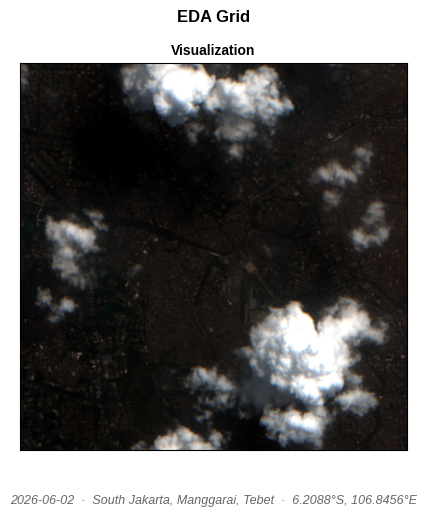

In [7]:
from geosave_engine.geodata.tile import GeoTile
from geosave_engine.utils.geovis import plot_eda_grid, RGBLayer

source.set_bands(["B04_10m", "B03_10m", "B02_10m"])  # Red, Green, Blue bands

lat, lon  = -6.2088, 106.8456  # Jakarta
size_m = 5000 # 5 km
resolution_m = 10 # each pixel represents 10 m
datetime = "2026-06-02/2026-06-04"

anchor = GeoTile.from_coordinate(lat, lon, size_m=size_m, resolution=resolution_m, datetime=datetime)
tile = source.load(anchor)

print(f"Tile dimensions: {tile.width} x {tile.height}")
print(f"Tile CRS: {tile.crs}")
print(f"Tile datetime: {tile.datetime}")

plot_eda_grid(
    layers=[RGBLayer("Visualization", tile)]
)

[########################################] | 100% Completed | 2.68 sms


(<Figure size 335x403 with 1 Axes>, array([<Axes: >], dtype=object))

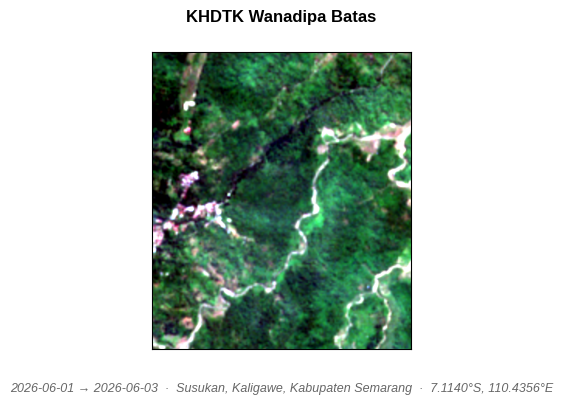

In [9]:
geojson = Path("data/khdtk_wanadipa_batas.geojson")

anchor_khdtk = GeoTile.from_geojson(geojson, resolution=5, datetime="2026-06-01/2026-06-04")[0]
tile_khdtk = source.load(anchor=anchor_khdtk)

plot_eda_grid(
    layers=[RGBLayer("", tile_khdtk)], title="KHDTK Wanadipa Batas"
)

In [ ]:
from functools import cached_property

import numpy as np
from scipy.ndimage import binary_opening

from geosave_engine.geodata.tile import GeoTile
from geosave_engine.geodata.features import (
    build_shadow_mask,
    compute_b10_mask,
    compute_cdi_mask,
    compute_ndvi,
    compute_s2c_mask,
)
from geosave_engine.geodata.pipeline import GeoPipeline, SourceProtocol
from geosave_engine.geodata.stac import StacClient

L1C_BANDS = [
    "B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08",
    "B09", "B10", "B11", "B12", "B8A",
]


class Pipeline(GeoPipeline):
    """Sentinel-2 imagery + cloud/shadow mask + NDVI for one anchor.

    Imagery only — DynamicWorld label prep is a separate, project-specific
    step (see ``workspace/scripts/dynamic_world_ingest``), writing
    ``dynamicworld.zarr`` directly into each anchor folder this pipeline's
    ``save_dataset()`` run already created. Not this class's concern: label
    remapping doesn't generalize across projects the way STAC-driven
    imagery ingest does.
    """

    def __init__(self) -> None:
        super().__init__(name="dynamicworld")

    @cached_property
    def sources(self) -> dict[str, SourceProtocol]:
        """Built lazily on first real fetch — importing/instantiating Pipeline
        for .context() alone must not cost a live STAC network call."""
        stac_client = StacClient.cdse()
        return {"sentinel_2_l1c": stac_client.source("sentinel-2-l1c", bands=L1C_BANDS, max_nodata_fraction=0.1)}

    def context(self, tiles: dict[str, GeoTile]) -> dict[str, object]:
        ref = next(iter(tiles.values()))
        return {
            "crs": ref.crs,
            "transform": ref.affine,
            "coordinate": ref.centroid,
            "time": ref.start.timetuple().tm_yday,
            "datetime": ref.start.isoformat(),
            "bbox_wgs84": list(ref.wgs84_bbox),
            "stac_item_ids": [i.id for i in ref.stac],
        }

    def preprocess(self, raw: dict[str, GeoTile]) -> dict[str, GeoTile]:
        s2 = raw["sentinel_2_l1c"]
        return {
            "sentinel_2_l1c": s2,
            "cloud_mask": self._ingest_cloud_mask(s2),
            "ndvi": self._ingest_ndvi(s2),
        }

    def _mask_one(self, ds, sun_az: float, resolution: float) -> np.ndarray:
        """Cloud + shadow mask for one time slice. `ds` has dims (band, y, x)."""
        s2c = compute_s2c_mask(
            b01=ds.sel(band="B01").values, b02=ds.sel(band="B02").values,
            b04=ds.sel(band="B04").values, b05=ds.sel(band="B05").values,
            b08=ds.sel(band="B08").values, b8a=ds.sel(band="B8A").values,
            b09=ds.sel(band="B09").values, b10=ds.sel(band="B10").values,
            b11=ds.sel(band="B11").values, b12=ds.sel(band="B12").values,
            prob_threshold=0.4,
        )
        cdi = compute_cdi_mask(
            b07=ds.sel(band="B07").values,
            b08=ds.sel(band="B08").values,
            b8a=ds.sel(band="B8A").values,
        )
        cirrus = compute_b10_mask(b10=ds.sel(band="B10").values, b10_threshold=0.0012)
        cloud_mask = binary_opening(s2c & cdi & cirrus, structure=np.ones((3, 3)))
        shadow_mask = build_shadow_mask(cloud_mask, sun_azimuth_deg=sun_az, resolution=int(resolution))
        return (cloud_mask | shadow_mask).astype(np.uint8)

    def _ingest_cloud_mask(self, s2: GeoTile) -> GeoTile:
        ds = s2.data
        # Sun azimuth varies slowly scene-to-scene for one location/season —
        # using the first matched item's for every time step is a fine approximation.
        sun_az = s2.stac[0].properties.get("view:sun_azimuth", 0.0)

        if s2.has_time:
            masks = [self._mask_one(ds.sel(time=t), sun_az, s2.resolution) for t in ds.time.values]
            stacked = np.stack(masks)[:, np.newaxis]  # (time, band=1, y, x)
            return s2.with_np(stacked, ["cloud_mask"], times=list(s2.times))

        mask = self._mask_one(ds, sun_az, s2.resolution)
        return s2.with_np(mask, ["cloud_mask"])

    def _ingest_ndvi(self, s2: GeoTile) -> GeoTile:
        ds = s2.data
        ndvi = compute_ndvi(nir=ds.sel(band="B08").values, red=ds.sel(band="B04").values)
        if s2.has_time:
            stacked = ndvi[:, np.newaxis].astype(np.float32)  # (time, band=1, y, x)
            return s2.with_np(stacked, ["ndvi"], times=list(s2.times))
        return s2.with_np(ndvi.astype(np.float32), ["ndvi"])


In [16]:
from geosave_engine.geodata.pipeline import save_dataset

root = Path("data/test_pipeline/test_ingest")

tiff_paths = [
    Path("data/dynamicworld_raw/train/Experts/EH/1/dw_111.5889659103_-0.0107497857-20190507.tif"),
    Path("data/dynamicworld_raw/train/Non_expert/WorkForce/EH/1/dw_113.0754367499_-2.5333440470-20190320.tif"),
    Path("data/dynamicworld_raw/train/Non_expert/WorkForce/EH/1/dw_111.8412562864_-8.1289167721-20190713.tif")
]

anchors = [GeoTile.from_geotiff(path) for path in tiff_paths]
save_dataset(Pipeline(), anchors=anchors, root=root)

result_path = []
for tile in root.iterdir():
    result_path.append(tile)
result_path

Saving dynamic_world:   0%|          | 0/3 [00:00<?, ?anchor/s]

[########################################] | 100% Completed | 78.94 ss


Saving dynamic_world:  33%|███▎      | 1/3 [01:42<03:24, 102.30s/anchor]

[########################################] | 100% Completed | 60.82 ss


Saving dynamic_world:  67%|██████▋   | 2/3 [02:48<01:21, 81.14s/anchor] 

[########################################] | 100% Completed | 75.88 ss


Saving dynamic_world: 100%|██████████| 3/3 [04:08<00:00, 82.78s/anchor]


[PosixPath('data/test_pipeline/test_ingest/dynamic_world'),
 PosixPath('data/test_pipeline/test_ingest/111.588981_-0.010766_20190507T000000_20190507T235959.999999_10m'),
 PosixPath('data/test_pipeline/test_ingest/113.075522_-2.533369_20190320T000000_20190320T235959.999999_10m'),
 PosixPath('data/test_pipeline/test_ingest/111.841261_-8.128952_20190713T000000_20190713T235959.999999_10m')]

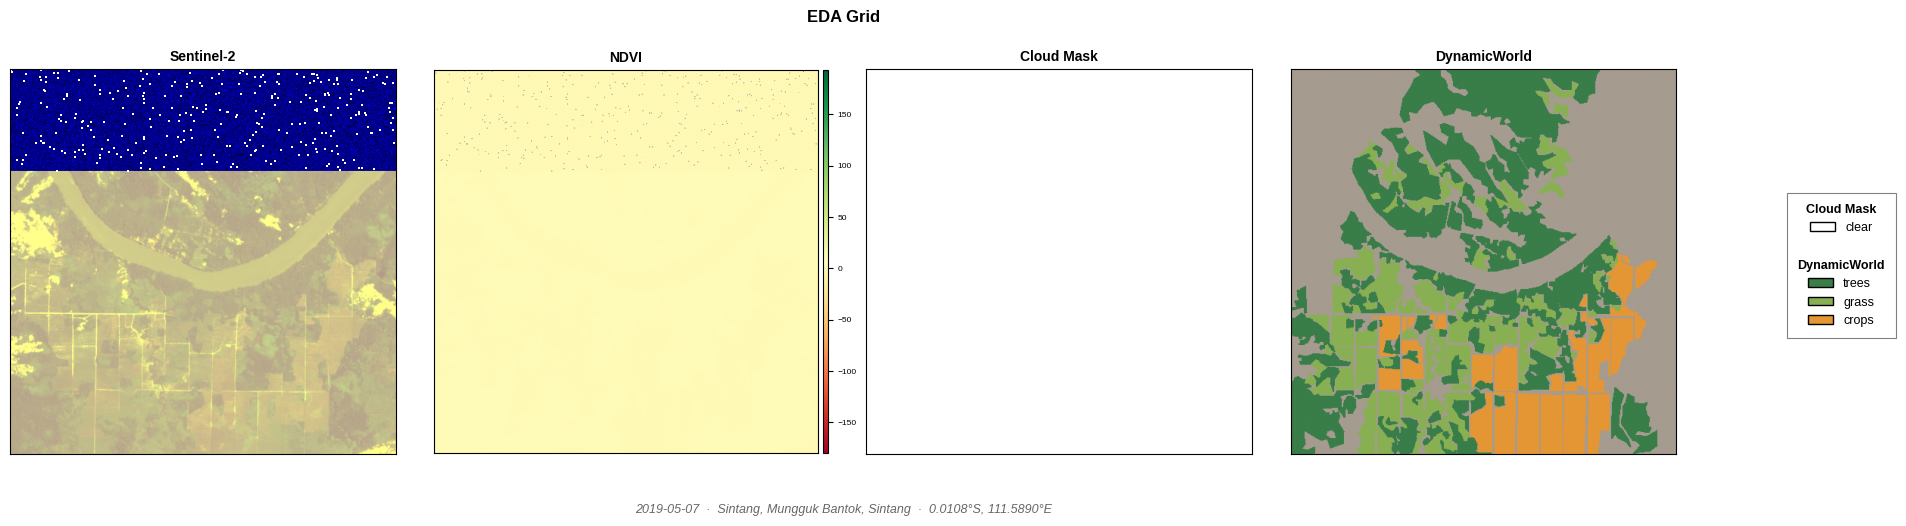

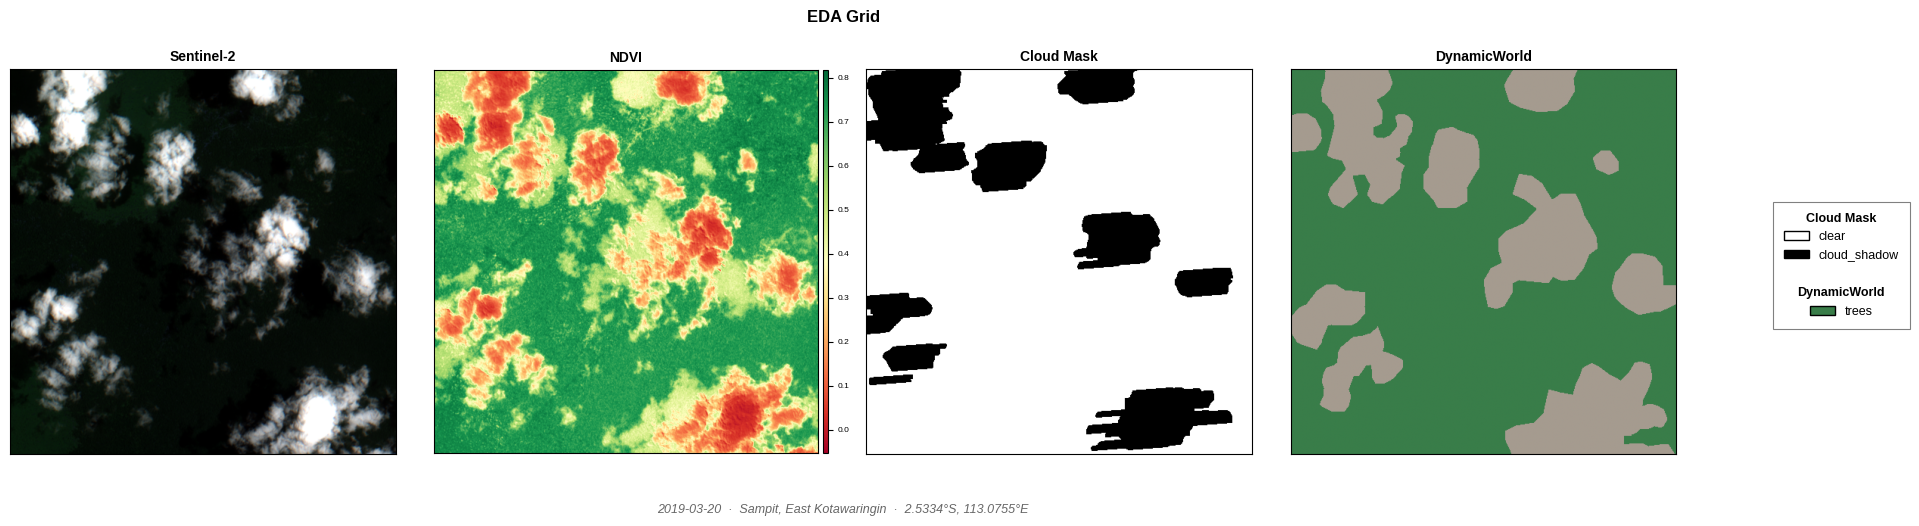

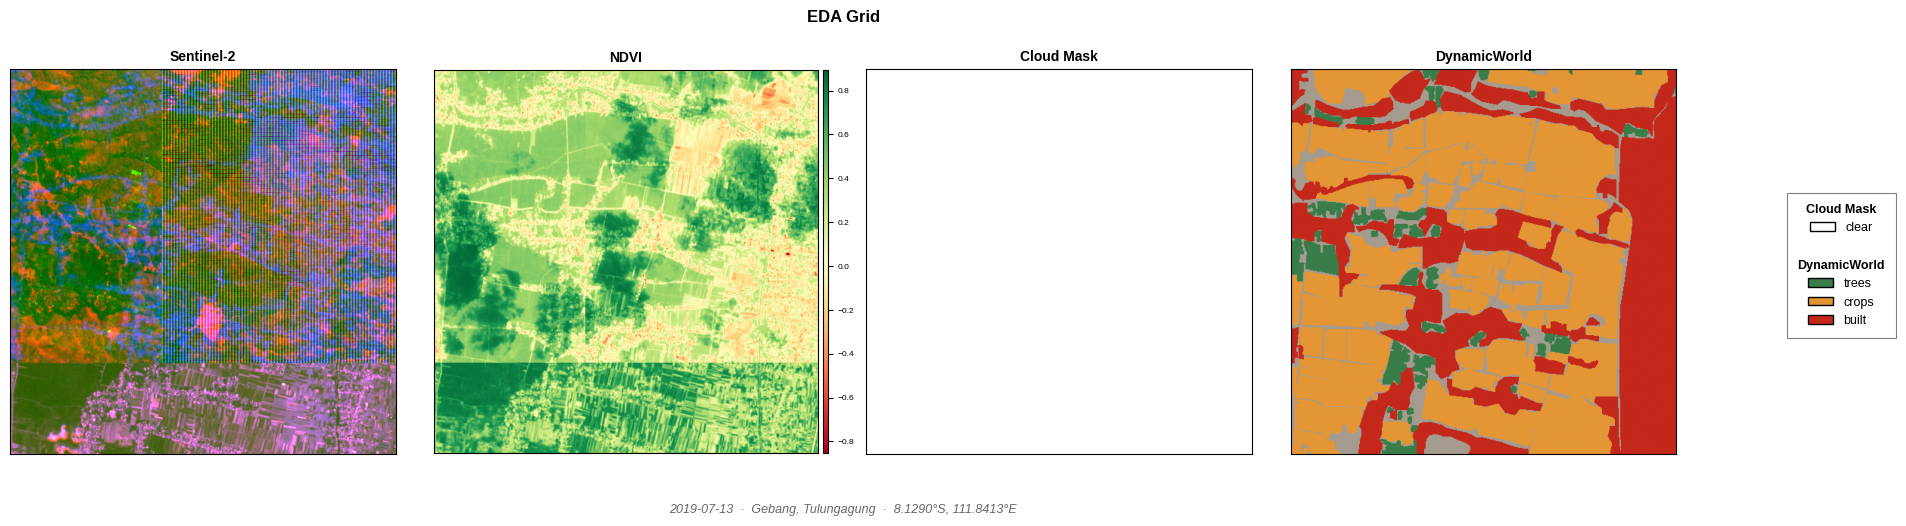

In [10]:
from geosave_engine.utils.geovis import plot_eda_grid, ContinuousLayer, RGBLayer, LabelLayer

for s2, cm, ndvi, dw in zip(*result_path.values()):
    layers = [
        RGBLayer("Sentinel-2", GeoTile.from_zarr(s2)),
        ContinuousLayer("NDVI", GeoTile.from_zarr(ndvi)),
        LabelLayer("Cloud Mask", GeoTile.from_zarr(cm), color_map=CloudMaskPipeline.color_map(), class_map=CloudMaskPipeline.class_map()),
        LabelLayer("DynamicWorld", GeoTile.from_zarr(dw), color_map=LabelPipeline.color_map(), class_map=LabelPipeline.class_map()),
    ]
    plot_eda_grid(layers, title="EDA Grid")

In [26]:
root = Path("data/test_pipeline/")

raw_dir = {
    "train": Path("data/dynamicworld_raw/train"),
    "val": Path("data/dynamicworld_raw/val"),
    "test": Path("data/dynamicworld_raw/test"),
}
for split, path in raw_dir.items():
    training_pipeline(root=root / split, geotiff_src=path, max_item=2)

Ingesting LabelPipeline: 100%|██████████| 2/2 [00:00<00:00, 5559.05tile/s]


In [32]:
import torch
from geosave_engine.geodata.datasets import GeoDataset

class DynamicWorldDataset(GeoDataset):
    output_key = {
        "sentinel_2_l1c": "image",
        "cloud_mask":      ("mask",  torch.bool),
        "ndvi":            ("ndvi",  torch.float32),
        "dynamicworld":    ("label", torch.int64),
    }

    def context(self, tiles: dict[str, GeoTile]) -> dict:
        """Add spatial and temporal metadata to each batch sample.

        Returns:
            {
                "crs": str,
                "transform": Affine,
                "coordinate": tuple[float, float],
                "time": int,  # day of year (1–365)
            }.
        """
        ref_tile = next(iter(tiles.values()))
        return {
            "crs": ref_tile.crs,
            "transform": ref_tile.affine,
            "coordinate": ref_tile.centroid,
            "time": ref_tile.datetime.timetuple().tm_yday,
        }


class DynamicWorldDatasetRGB(DynamicWorldDataset):
    """RGB-only variant — loads B04/B03/B02 instead of all S2 bands."""

    sel_bands = {
        "sentinel_2_l1c": ["B04", "B03", "B02"],
    }

ds = DynamicWorldDatasetRGB(root / "train")
sample = ds[0]
print("Sample keys:", sample.keys())

Sample keys: dict_keys(['mask', 'label', 'ndvi', 'image', 'context'])


In [34]:
from torch.utils.data import DataLoader
from geosave_engine.geodata.datasets import stack_samples

dataloader = DataLoader(ds, batch_size=2, collate_fn=stack_samples)
for idx, batch in enumerate(dataloader):
    print(f"Batch {idx}:")
    print(f"  Keys: {list(batch.keys())}")
    print(f"  Context: {batch['context']}")
    print(f"  Image shape: {batch['image'].shape}") # (B, T, C, H, W)
    print(f"  Mask shape: {batch['mask'].shape}") # (B, T, C, H, W)
    print(f"  Label shape: {batch['label'].shape}")

Batch 0:
  Keys: ['mask', 'context', 'ndvi', 'label', 'image']
  Context: {'transform': [Affine(10.0, 0.0, 328030.0,
       0.0, -10.0, 950060.0), Affine(10.0, 0.0, 238370.0,
       0.0, -10.0, 1144570.0)], 'time': [29, 349], 'coordinate': [(-10.539430069537929, 8.568712441847218), (-11.365703686126919, 10.322423696210326)], 'crs': ['EPSG:32629', 'EPSG:32629']}
  Image shape: torch.Size([2, 3, 510, 510])
  Mask shape: torch.Size([2, 1, 510, 510])
  Label shape: torch.Size([2, 1, 510, 510])


In [ ]:
"""
Coordinate: latitude, longitude in spatial coordinates in WGS84 (EPSG:4326)

Stored as:
    [latitude, longitude]
"""
batch = next(iter(dataloader))
centroid = batch['context']["coordinate"][0] # drop the extra dimension from stacking, same value repeated across layers
centroid

(-10.539430069537929, 8.568712441847218)

In [39]:
"""
Time: day of year (1–365)

Stored as:
    int
"""
batch = next(iter(dataloader))
time = batch['context']["time"][0] # drop the extra dimension from stacking, same value repeated across layers
time

29

In [40]:
from affine import Affine
"""
affine pixel-to-spatial transform.

Stored as:
    [a, b, c, d, e, f, 0, 0, 1]

Meaning:
    a: pixel width.
    b: row rotation or shear, usually 0.
    c: x coordinate of the upper-left pixel origin.
    d: column rotation or shear, usually 0.
    e: pixel height, usually negative for north-up rasters.
    f: y coordinate of the upper-left pixel origin.

Use:
    latitude, longitude = Affine(a, b, c, d, e, f) * (col, row)
"""
batch = next(iter(dataloader))
affine = batch['context']["transform"][0] # drop the extra dimension from stacking, same value repeated across layers
affine = Affine(*affine)
affine * (0, 0) # upper-left pixel origin in spatial coordinates

(328030.0, 950060.0)

In [45]:
from modules.data_module import GeosaveDataModule # ty:ignore[unresolved-import]

# Predownloading Data

split_dirs = {
    "train": Path("data/dynamicworld_raw/train"),
    "val": Path("data/dynamicworld_raw/val"),
    "test": Path("data/dynamicworld_raw/test"),
}

root = Path("data/test_pipeline/")

dm = GeosaveDataModule(
    root=root,
    split_dirs=split_dirs,
    max_tiles=4,
    batch_size=2,
    ingest=True,
)

dm.prepare_data()
dm.setup("fit")

Ingesting LabelPipeline: 100%|██████████| 4/4 [00:00<00:00, 7297.61tile/s]


In [46]:
loader = dm.train_dataloader()
batch = next(iter(loader))
batch

{'mask': tensor([[[[False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]]],
 
 
         [[[False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]]]]),
 'context': {'transform': [Affine(10.0, 0.0, 328030.0,
          0.0, -10.0, 950060.0),
   Affine(10.0, 0.0, 238370.0,
          0.0, -10.0, 1144570.0)],
  'time': [29, 349],
  'coordinate': [(-10.539430069537929, 8.56

In [47]:
from modules.lightning_module import GeosaveLightningModule # ty:ignore[unresolved-import]
from lightning import Trainer

input_size = (224, 224) # Resize input images to 224x224 for the model

augmentations = [
    {
        "name": "RandomCrop",
        "init_args": {"size": input_size},
    },
]

module = GeosaveLightningModule(
    input_size=input_size,
    in_channels=3,  # RGB-only dataset from DynamicWorldDatasetRGB
    augmentations=augmentations,
    config={"encoder": {
        "model_name": "vit_small_patch16_dinov3.lvd1689m",
        "pretrained": False
        }
    }
)

trainer = Trainer(
    fast_dev_run=True,  # Run a single batch for testing
    accelerator="auto",  # Use GPU if available
    logger=False,  # Disable logging for this test
    enable_checkpointing=False,  # Disable checkpointing for this test
)

trainer.fit(module, datamodule=dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
Ingesting LabelPipeline: 100%|██████████| 4/4 [00:00<00:00, 5065.58tile/s]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss_fn       │ CrossEntropyLoss            │      0 │ train │     0 │
│ 1 │ train_metrics │ SemanticSegmentationMetrics │      0 │ train │     0 │
│ 2 │ val_metrics   │ SemanticSegmentationMetrics │      0 │ train │     0 │
│ 3 │ test_metrics  │ SemanticSegmentationMetrics │      0 │ train │     0 │
│ 4 │ model         │ SemanticSegmentation        │ 51.6 M │ train │     0 │
│ 5 │ augmenter     │ ImageAugmenter              │      0 │ train │     0 │
│ 6 │ preprocessor  │ ImageProcessor              │      0 │ train │     0 │
└───┴───────────────┴─────────────────────────────┴────────┴───────┴───────┘

Trainable params: 51.6 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 51.6 M                                                                                               
Total estimated model params size (MB): 206                                                                        
Modules in train mode: 381                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=1` reached.
